In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

gradient_boosting_estimators_dict = {
    "Gradient Boosting": estimators_dict["Gradient Boosting"],
    "Gradient Boosting Balanced": estimators_dict["Gradient Boosting Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_gb, threshold_comparison_gb, confusion_results_gb, trained_models_gb, interpretation_results_gb = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=gradient_boosting_estimators_dict,
    target=target
)

general_comparison_gb.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
17,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.5,0.821,0.457,0.606,0.521,0.834,3,8,25
5,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.5,0.785,0.400,0.676,0.503,0.799,0,8,21
11,Modelo 6 — Perfil Pessoal,Gradient Boosting Balanced,0.5,0.794,0.407,0.620,0.492,0.795,0,9,24
13,Modelo 7 — Reduzido Conservador,Gradient Boosting Balanced,0.5,0.773,0.382,0.662,0.485,0.767,0,7,18
29,Modelo 8 — Integrado Multidimensional,Gradient Boosting Balanced,0.5,0.819,0.446,0.521,0.481,0.797,7,11,43
9,Modelo 5 — Estabilidade e Benefícios,Gradient Boosting Balanced,0.5,0.773,0.380,0.648,0.479,0.785,0,9,24
3,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.5,0.762,0.369,0.676,0.478,0.805,0,8,22
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Gradient Boosting Balanced,0.5,0.807,0.422,0.535,0.472,0.798,3,8,24
15,Modelo 1 — Função Profissional Misto,Gradient Boosting Balanced,0.5,0.791,0.396,0.563,0.465,0.776,3,7,26
23,Modelo 5 — Antiguidade Organizacional,Gradient Boosting Balanced,0.5,0.796,0.400,0.535,0.458,0.777,5,6,20


In [4]:
best_thresholds_gb = threshold_comparison_gb.loc[
    threshold_comparison_gb.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_gb.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
6,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting,0.225,0.844,0.512,0.606,0.555,0.826
7,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.425,0.800,0.431,0.746,0.546,0.834
8,Modelo 3 — Faixa Salarial,Gradient Boosting,0.275,0.844,0.513,0.549,0.531,0.797
4,Modelo 2 — Nível Hierárquico,Gradient Boosting,0.325,0.844,0.514,0.535,0.524,0.815
5,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.650,0.839,0.500,0.535,0.517,0.805
20,Modelo 6 — Perfil Pessoal,Gradient Boosting,0.225,0.825,0.466,0.577,0.516,0.803
9,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.525,0.798,0.420,0.662,0.514,0.799
29,Modelo 8 — Integrado Multidimensional,Gradient Boosting Balanced,0.600,0.855,0.559,0.465,0.508,0.797
21,Modelo 6 — Perfil Pessoal,Gradient Boosting Balanced,0.450,0.780,0.397,0.704,0.508,0.795
19,Modelo 5 — Estabilidade e Benefícios,Gradient Boosting Balanced,0.550,0.800,0.417,0.606,0.494,0.785


In [5]:
top_5_best_gb = best_thresholds_gb.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_gb

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting,0.225,0.844,0.512,0.606,0.555,0.826
1,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.425,0.800,0.431,0.746,0.546,0.834
2,Modelo 3 — Faixa Salarial,Gradient Boosting,0.275,0.844,0.513,0.549,0.531,0.797
3,Modelo 2 — Nível Hierárquico,Gradient Boosting,0.325,0.844,0.514,0.535,0.524,0.815
4,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.650,0.839,0.500,0.535,0.517,0.805


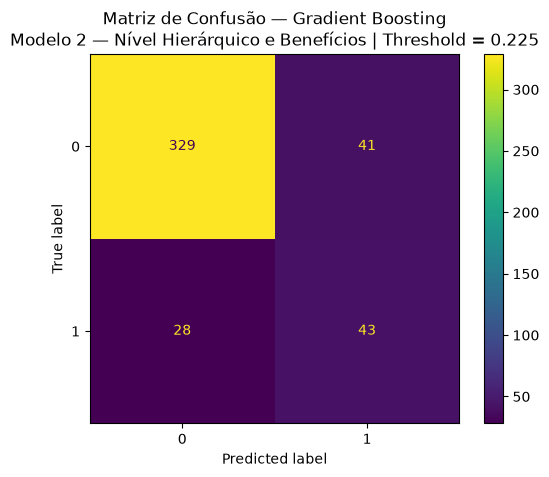

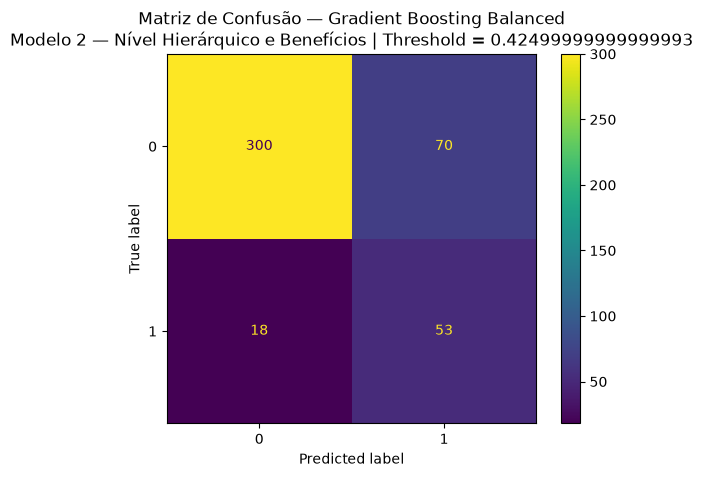

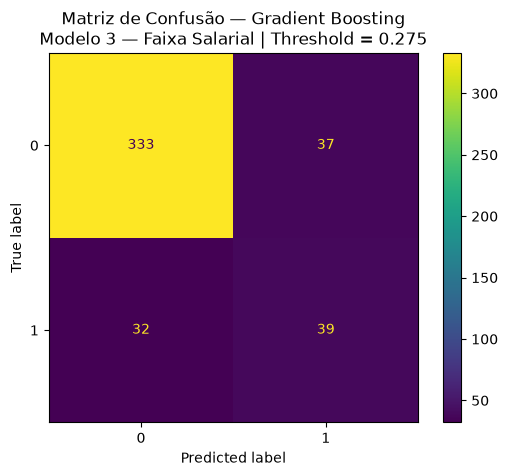

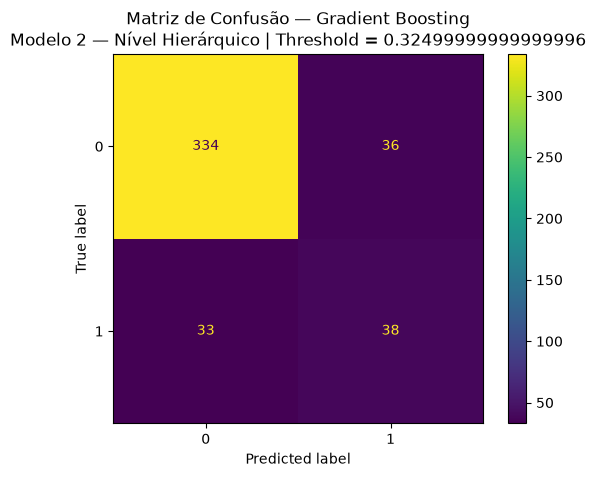

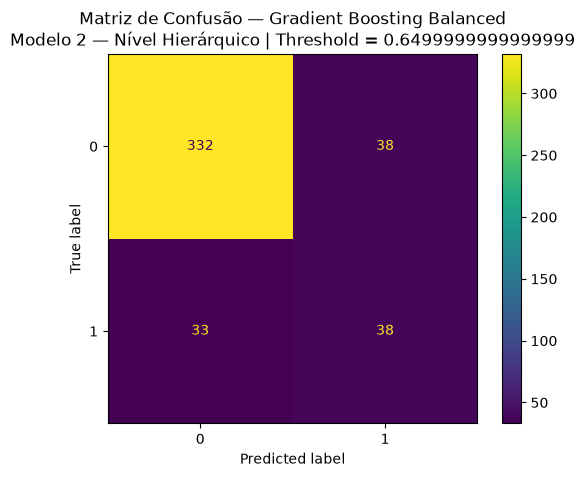

In [6]:
for _, row in top_5_best_gb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(gradient_boosting_estimators_dict[model_name]["estimator"])
    balance_method = gradient_boosting_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

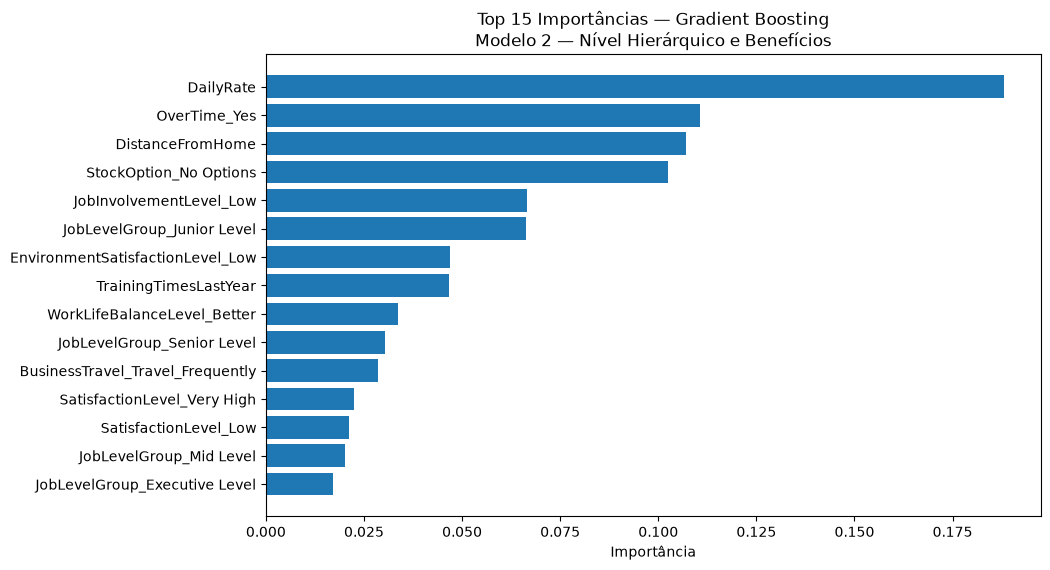

,Feature,Importance
1,DailyRate,0.188108
3,OverTime_Yes,0.110688
0,DistanceFromHome,0.107055
10,StockOption_No Options,0.102482
13,JobInvolvementLevel_Low,0.066654
5,JobLevelGroup_Junior Level,0.066278
16,EnvironmentSatisfactionLevel_Low,0.047013
2,TrainingTimesLastYear,0.046621
23,WorkLifeBalanceLevel_Better,0.033608
7,JobLevelGroup_Senior Level,0.030405


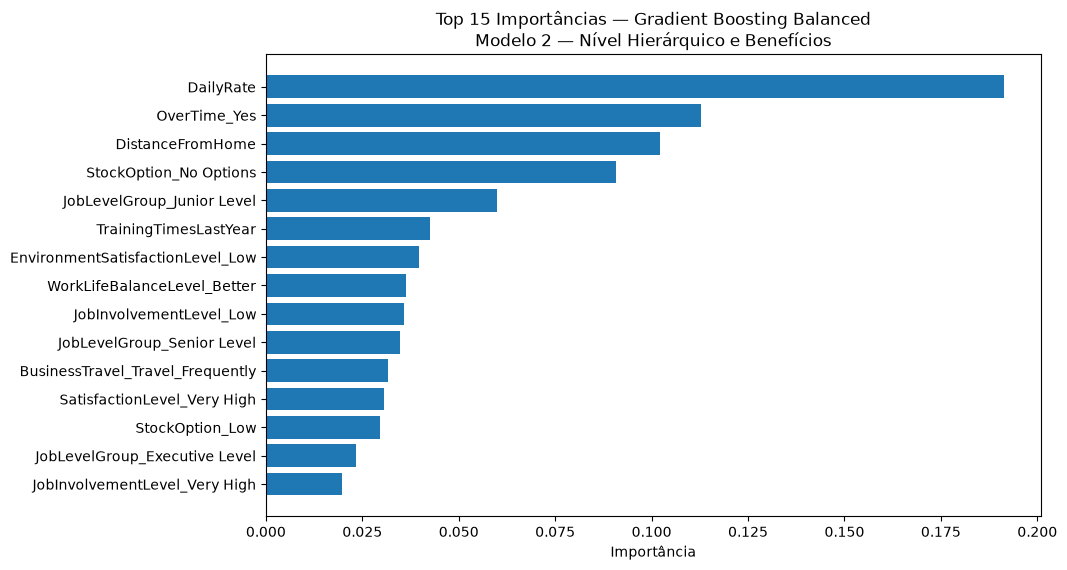

,Feature,Importance
1,DailyRate,0.191364
3,OverTime_Yes,0.112872
0,DistanceFromHome,0.102083
10,StockOption_No Options,0.090673
5,JobLevelGroup_Junior Level,0.060044
2,TrainingTimesLastYear,0.042539
16,EnvironmentSatisfactionLevel_Low,0.039736
23,WorkLifeBalanceLevel_Better,0.036386
13,JobInvolvementLevel_Low,0.035868
7,JobLevelGroup_Senior Level,0.034706


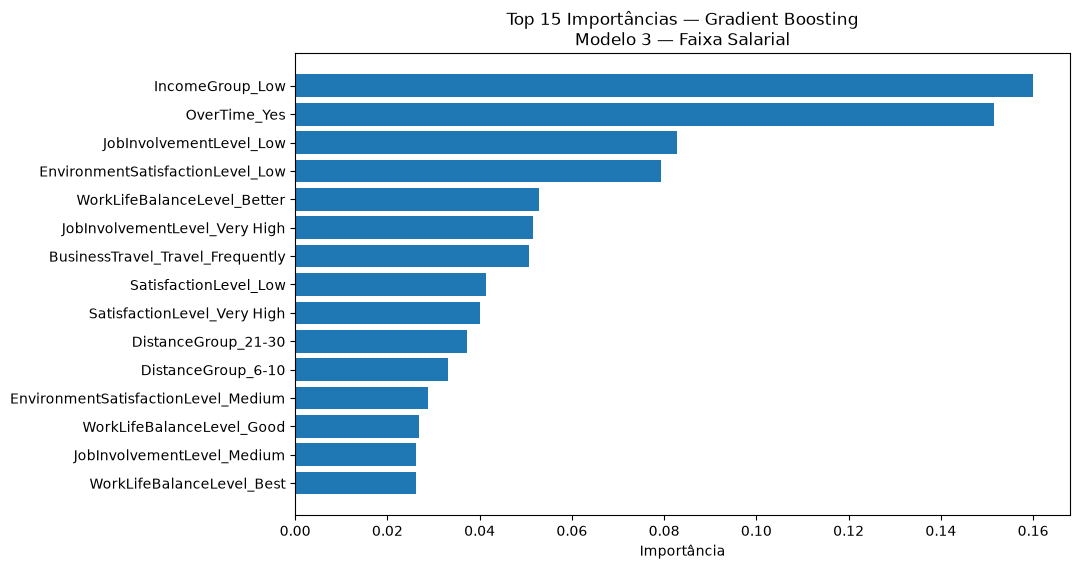

,Feature,Importance
1,IncomeGroup_Low,0.160032
0,OverTime_Yes,0.151477
6,JobInvolvementLevel_Low,0.082789
9,EnvironmentSatisfactionLevel_Low,0.079310
16,WorkLifeBalanceLevel_Better,0.052797
8,JobInvolvementLevel_Very High,0.051469
4,BusinessTravel_Travel_Frequently,0.050767
12,SatisfactionLevel_Low,0.041291
14,SatisfactionLevel_Very High,0.040091
19,DistanceGroup_21-30,0.037208


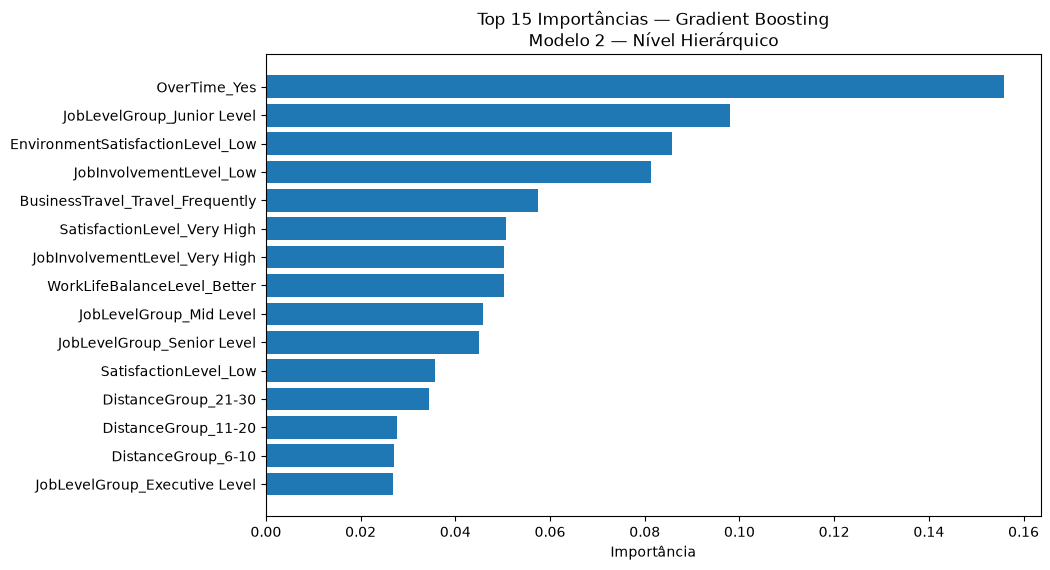

,Feature,Importance
0,OverTime_Yes,0.155866
2,JobLevelGroup_Junior Level,0.098056
10,EnvironmentSatisfactionLevel_Low,0.085777
7,JobInvolvementLevel_Low,0.081265
5,BusinessTravel_Travel_Frequently,0.057521
15,SatisfactionLevel_Very High,0.050670
9,JobInvolvementLevel_Very High,0.050328
17,WorkLifeBalanceLevel_Better,0.050231
3,JobLevelGroup_Mid Level,0.045745
4,JobLevelGroup_Senior Level,0.044969


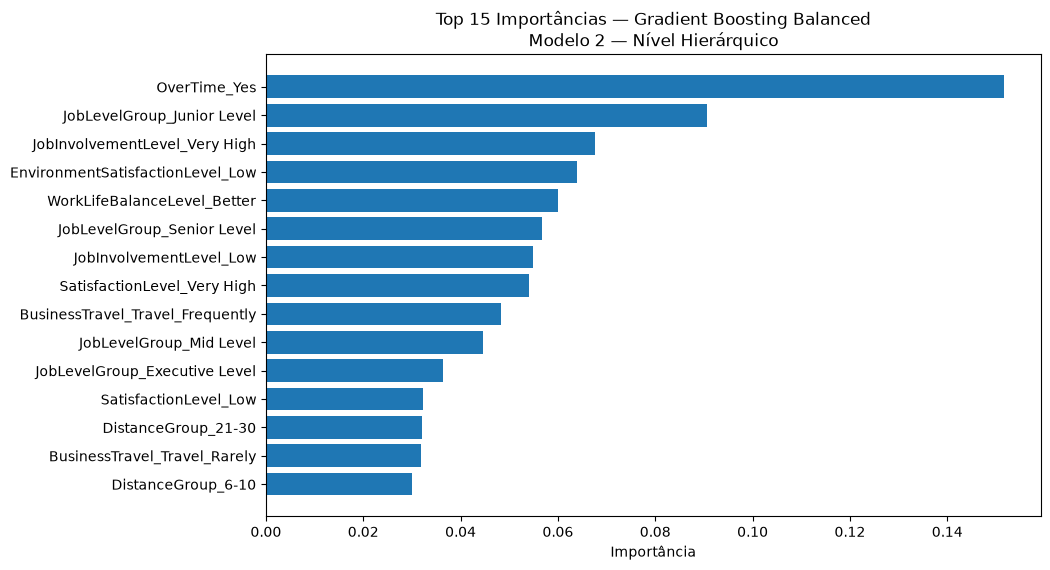

,Feature,Importance
0,OverTime_Yes,0.151654
2,JobLevelGroup_Junior Level,0.090565
9,JobInvolvementLevel_Very High,0.067576
10,EnvironmentSatisfactionLevel_Low,0.064007
17,WorkLifeBalanceLevel_Better,0.060069
4,JobLevelGroup_Senior Level,0.056643
7,JobInvolvementLevel_Low,0.054941
15,SatisfactionLevel_Very High,0.054134
5,BusinessTravel_Travel_Frequently,0.048343
3,JobLevelGroup_Mid Level,0.044637


In [7]:
for _, row in top_5_best_gb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_gb[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — Gradient Boosting | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


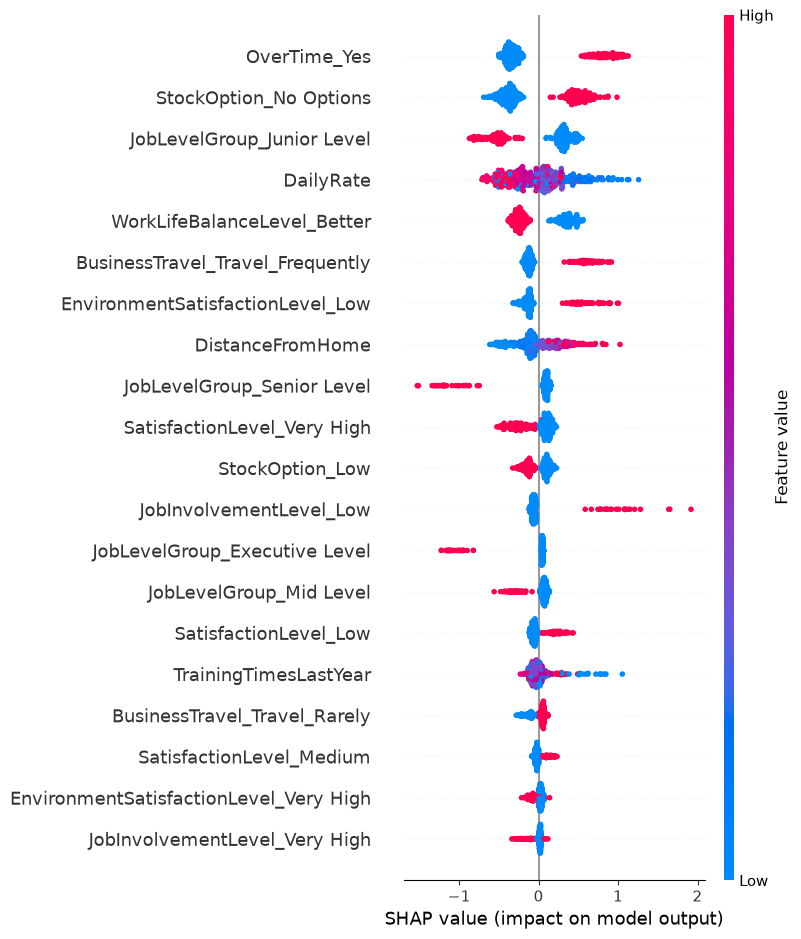

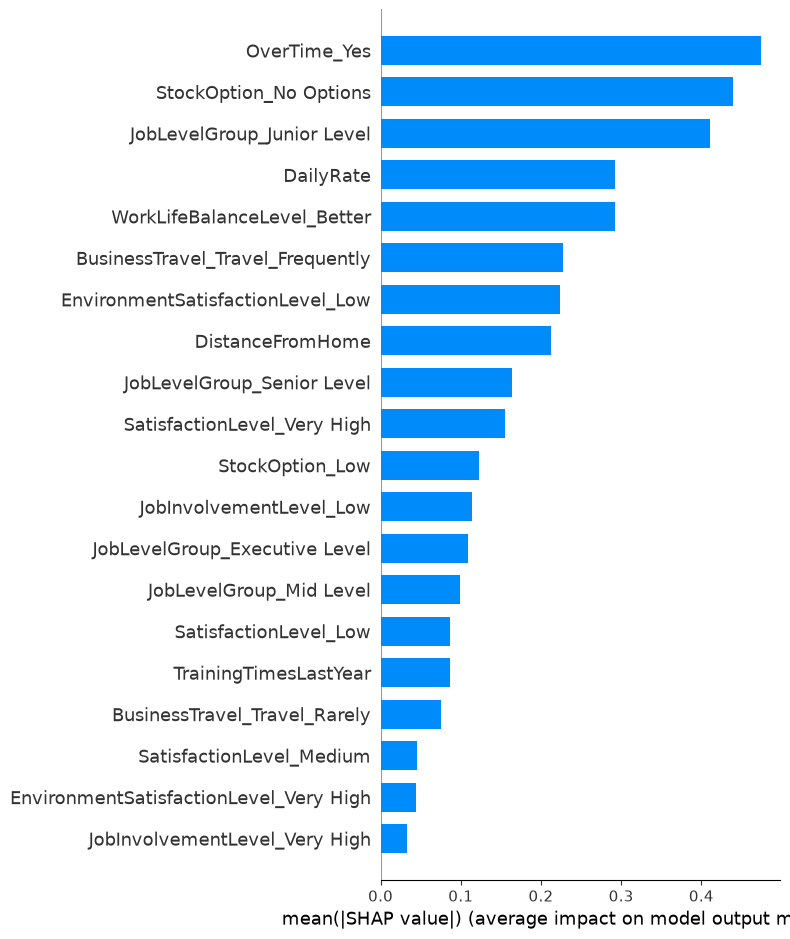

SHAP — Gradient Boosting Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


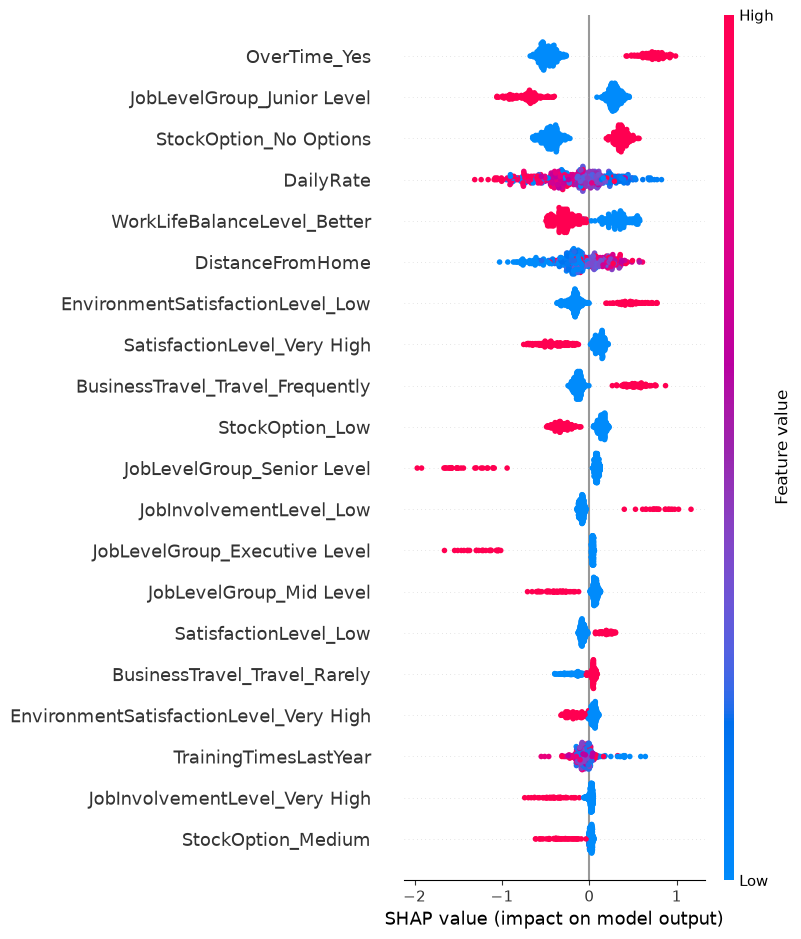

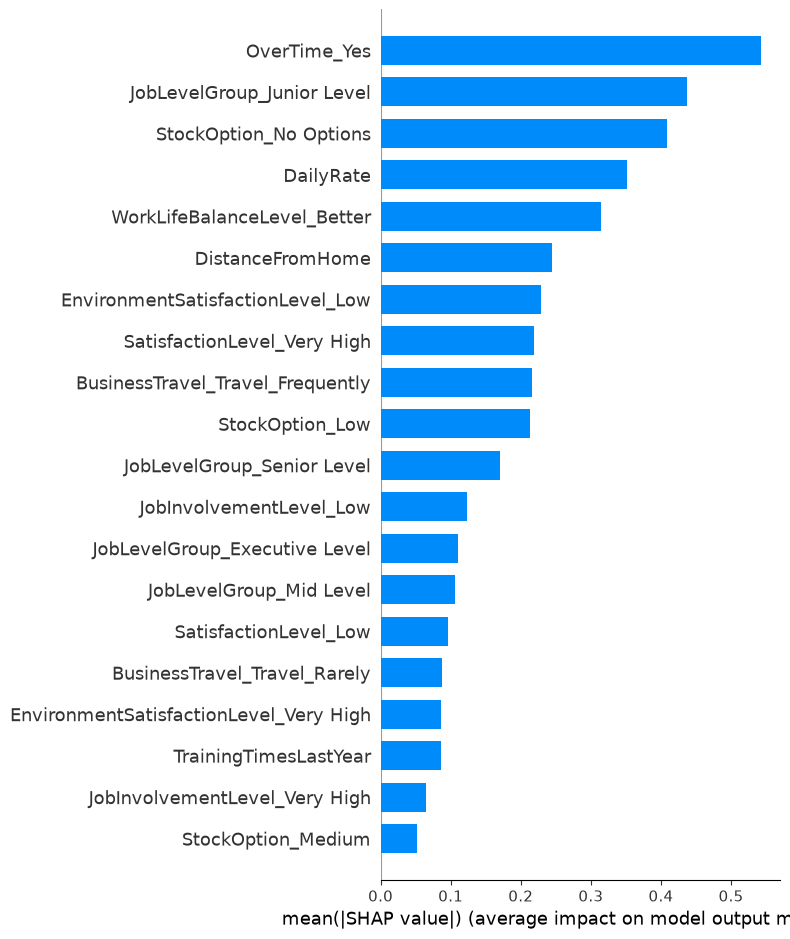

SHAP — Gradient Boosting | Modelo 3 — Faixa Salarial
(441, 21)
(441, 21)


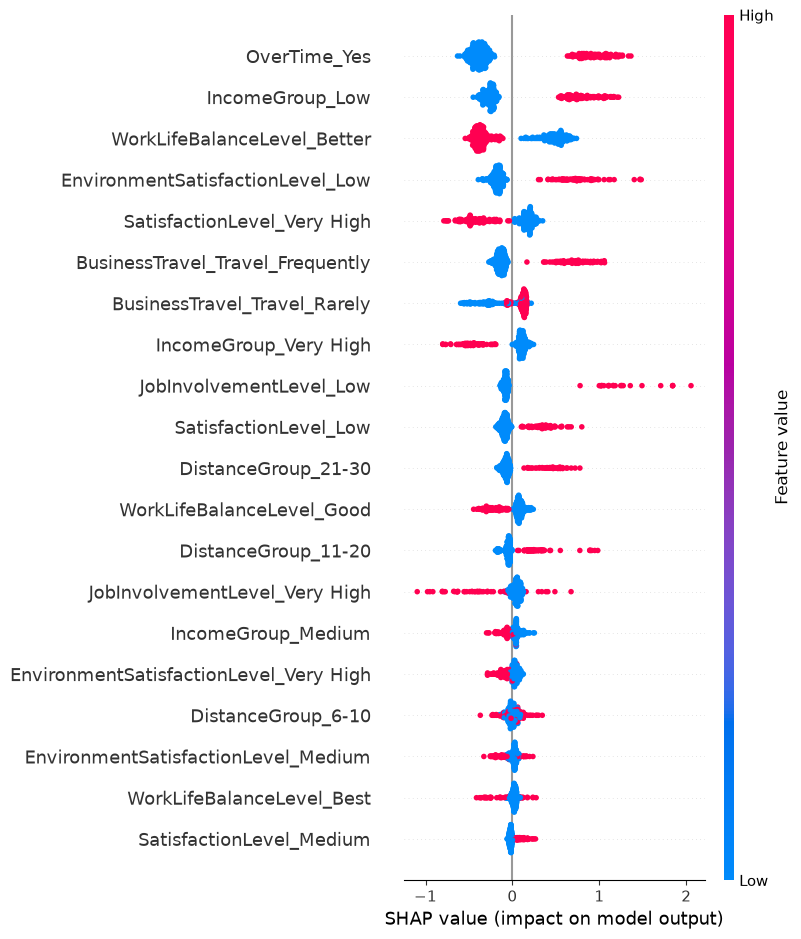

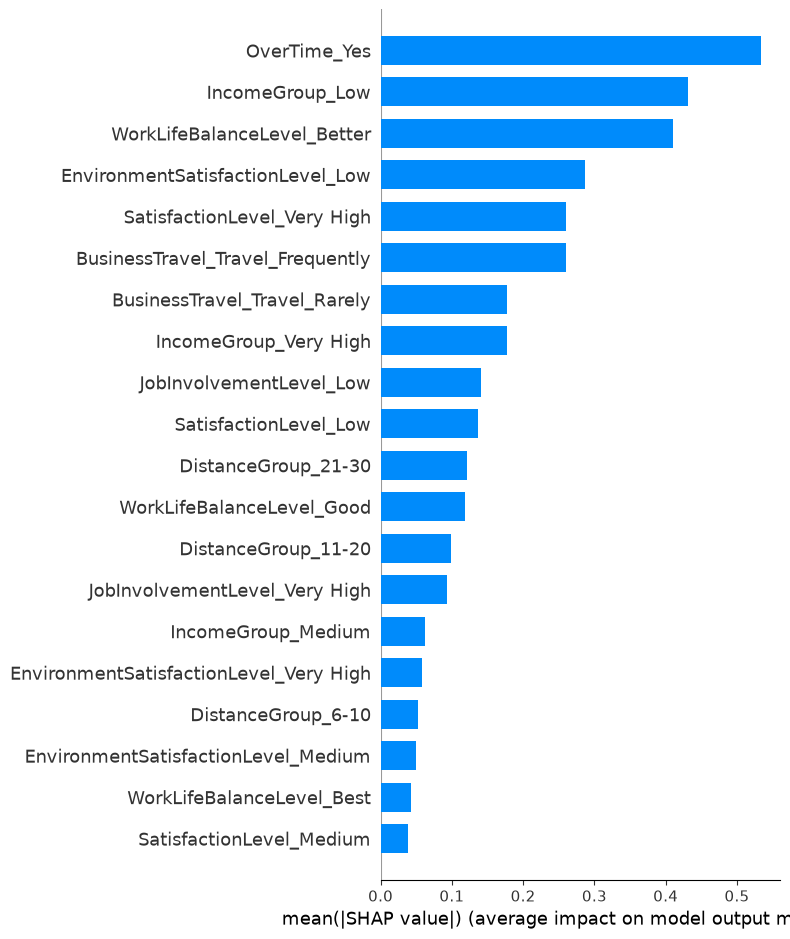

SHAP — Gradient Boosting | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


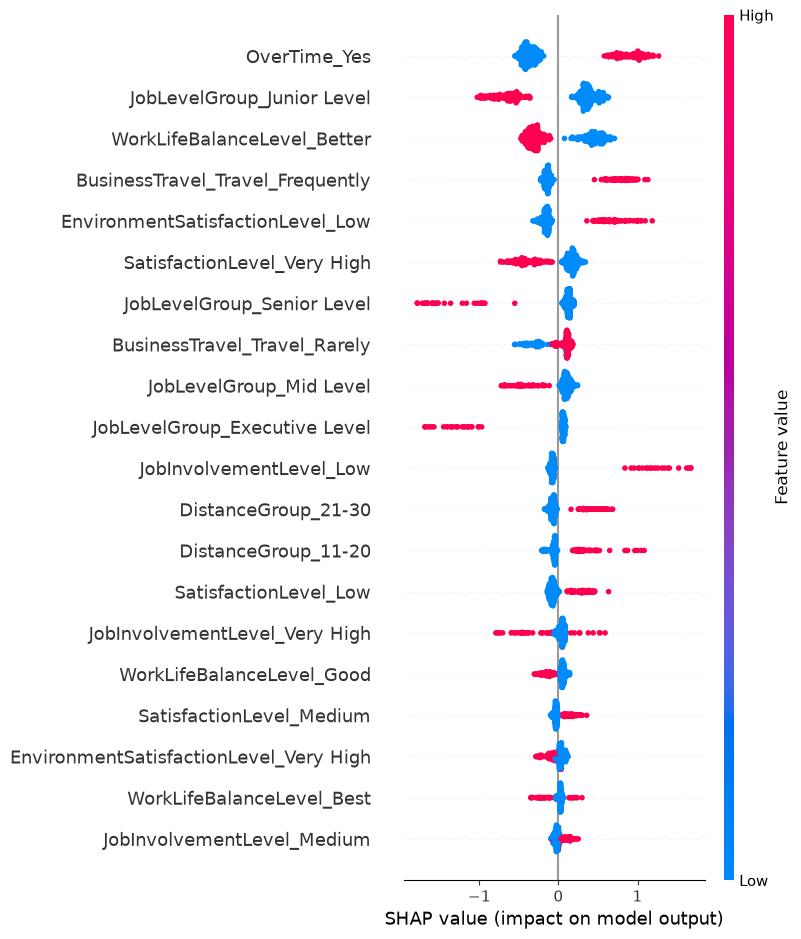

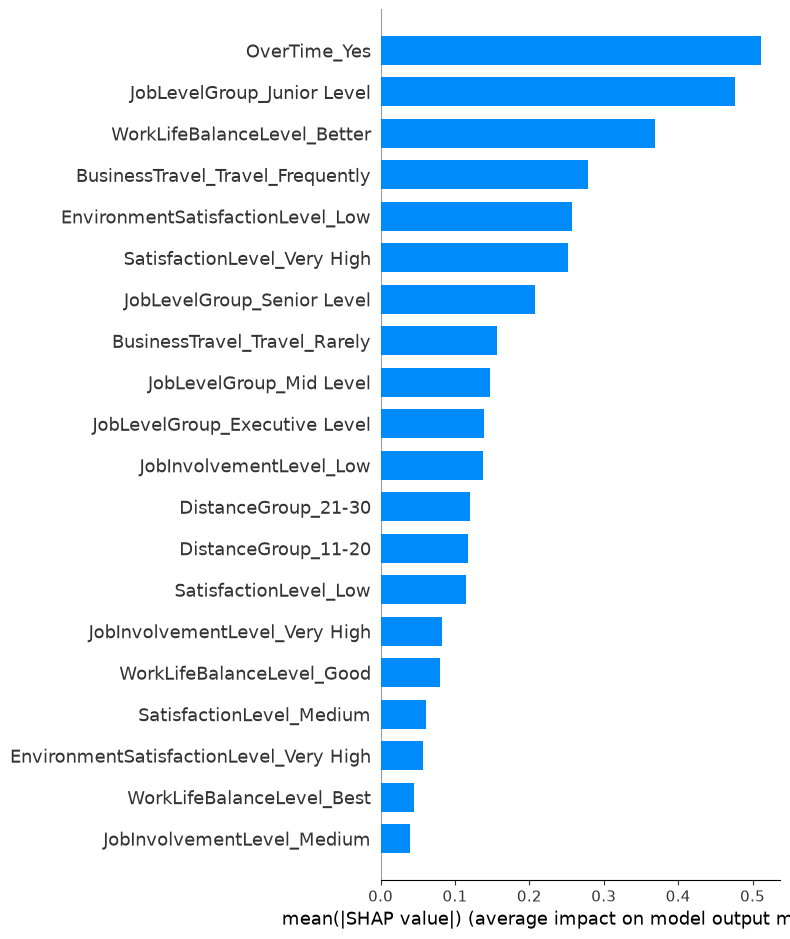

SHAP — Gradient Boosting Balanced | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


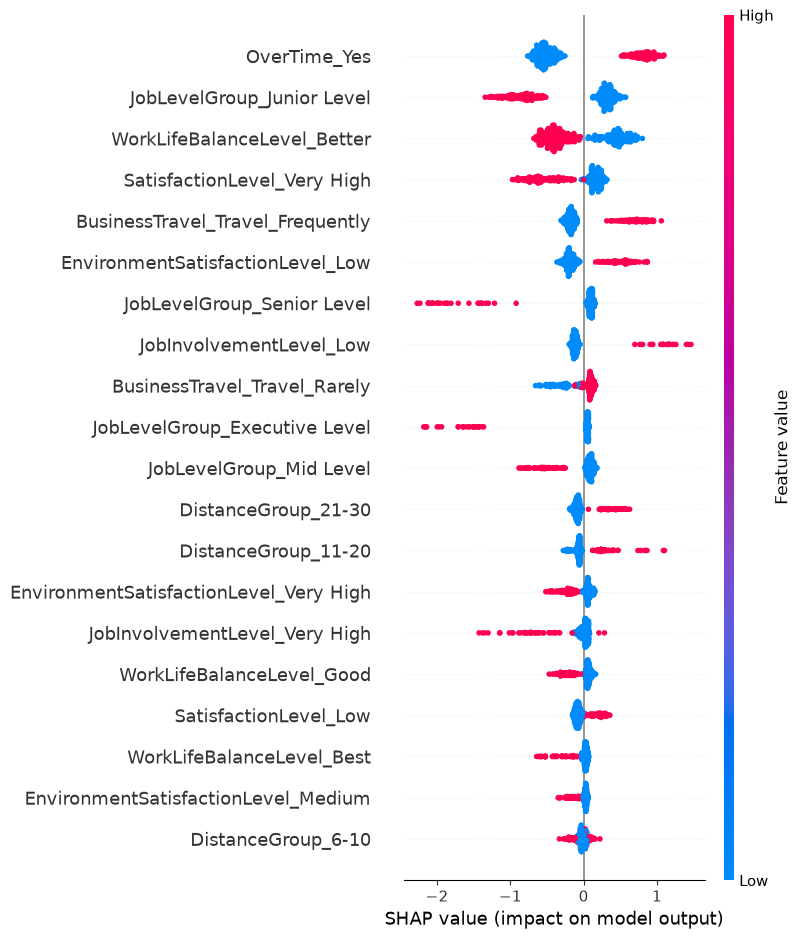

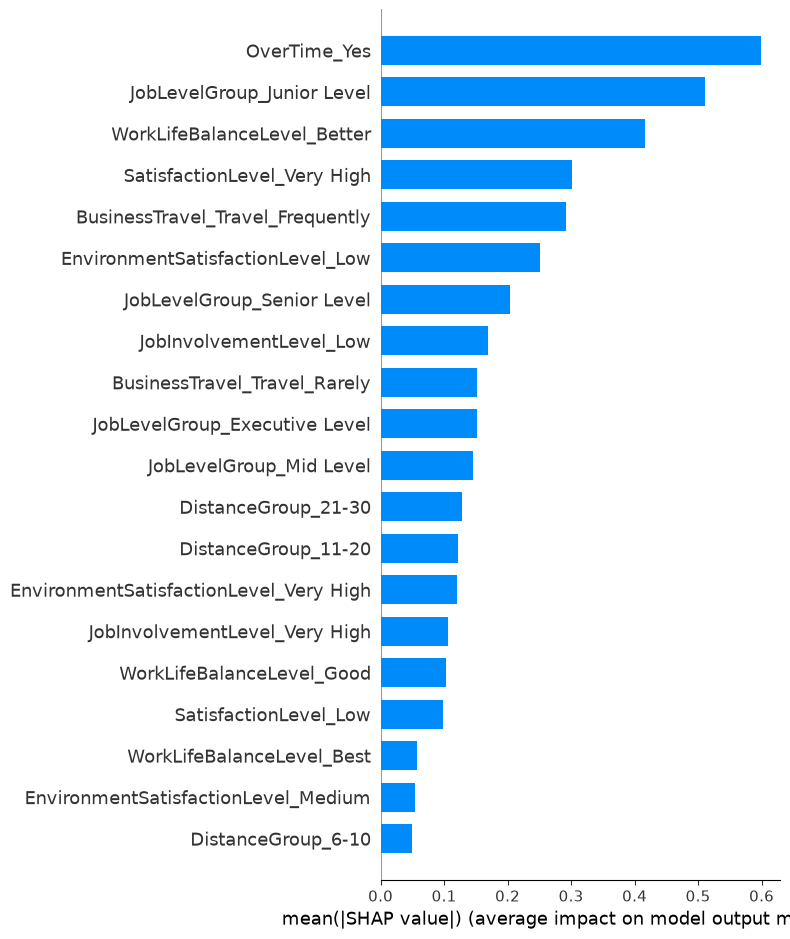

In [8]:
for _, row in top_5_best_gb.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(gradient_boosting_estimators_dict[model_name]["estimator"])
    balance_method = gradient_boosting_estimators_dict[model_name].get("balance_method", None)
    
    if balance_method == "sample_weight":
        
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )
        
        estimator.fit(X_train, y_train, sample_weight=sample_weight)
        
    else:
        estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_gradient = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Gradient Boosting": estimators_dict["Gradient Boosting"],
        "Gradient Boosting Balanced": estimators_dict["Gradient Boosting Balanced"]
    },
    target="AttritionFlag"
)

cv_gradient.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,Gradient Boosting Balanced,0.814,0.022,0.444,0.053,0.590,0.099,0.504,0.060,0.808,0.049,7,11,43
7,Modelo 4 — Trajetória Organizacional,Gradient Boosting Balanced,0.768,0.041,0.384,0.064,0.687,0.093,0.490,0.068,0.776,0.046,0,8,22
17,Modelo 2 — Nível Hierárquico e Benefícios,Gradient Boosting Balanced,0.783,0.021,0.389,0.036,0.603,0.089,0.471,0.046,0.778,0.040,3,8,25
1,Modelo 1 — Função Profissional,Gradient Boosting Balanced,0.762,0.028,0.368,0.046,0.653,0.093,0.469,0.053,0.772,0.042,0,8,26
9,Modelo 5 — Estabilidade e Benefícios,Gradient Boosting Balanced,0.761,0.038,0.366,0.054,0.628,0.087,0.459,0.055,0.779,0.042,0,9,24
11,Modelo 6 — Perfil Pessoal,Gradient Boosting Balanced,0.760,0.027,0.360,0.042,0.624,0.089,0.455,0.052,0.775,0.046,0,9,24
21,Modelo 4 — Experiência Profissional,Gradient Boosting Balanced,0.775,0.041,0.378,0.061,0.574,0.062,0.454,0.059,0.758,0.050,4,6,19
5,Modelo 3 — Faixa Salarial,Gradient Boosting Balanced,0.760,0.040,0.362,0.057,0.615,0.102,0.453,0.061,0.767,0.061,0,8,21
19,Modelo 3 — Rendimento Quantitativo,Gradient Boosting Balanced,0.776,0.031,0.376,0.051,0.565,0.043,0.450,0.046,0.767,0.050,4,6,19
3,Modelo 2 — Nível Hierárquico,Gradient Boosting Balanced,0.749,0.026,0.344,0.043,0.614,0.103,0.440,0.059,0.766,0.052,0,8,22
